In [2]:
import pandas as pd

ndvi = pd.read_csv("../02_data/processed/Kenya_ASAL_NDVI_Clean_2019_2026.csv")

## NDVI Data Source

The NDVI vegetation data was extracted from Google Earth Engine using the MODIS Terra Vegetation Indices product:

- Dataset: MODIS/061/MOD13Q1
- Variable: NDVI
- Spatial resolution: 250 meters
- Temporal resolution: 16-day composite
- Study area: Kenya ASAL counties
- Period: 2019–2026

The extraction was done in Google Colab because Google Earth Engine integrates easily with Colab and Google Drive. The exported county-level monthly NDVI data was cleaned and saved as:

`02_data/processed/Kenya_ASAL_NDVI_Clean_2019_2026.csv`

This file contains monthly NDVI values, 1-month, 3-month, and 6-month rolling averages, and NDVI anomaly values for each county.

In [3]:
# Check the size of the NDVI dataset
print("NDVI shape:", ndvi.shape)

# Show the first few rows
ndvi.head()

NDVI shape: (2023, 7)


,county,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,Baringo,2019-01-01,0.434380,0.434380,0.434380,0.434380,-0.020150
1,Baringo,2019-02-01,0.355929,0.355929,0.395155,0.395155,-0.056828
2,Baringo,2019-03-01,0.349627,0.349627,0.379979,0.379979,-0.091802
3,Baringo,2019-04-01,0.354903,0.354903,0.353486,0.373710,-0.187785
4,Baringo,2019-05-01,0.408462,0.408462,0.370998,0.380660,-0.182011


In [4]:
# Check column names and data types
ndvi.info()

<class 'pandas.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   county             2023 non-null   str    
 1   date               2023 non-null   str    
 2   mean_ndvi          2023 non-null   float64
 3   ndvi_1_month_mean  2023 non-null   float64
 4   ndvi_3_month_mean  2023 non-null   float64
 5   ndvi_6_month_mean  2023 non-null   float64
 6   ndvi_anomaly       2023 non-null   float64
dtypes: float64(5), str(2)
memory usage: 110.8 KB


In [5]:
# Convert NDVI date column to proper datetime format
ndvi["date"] = pd.to_datetime(ndvi["date"])

# Convert to monthly date format
ndvi["date"] = ndvi["date"].dt.to_period("M").dt.to_timestamp()

# Check result
ndvi.head()

,county,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,Baringo,2019-01-01,0.434380,0.434380,0.434380,0.434380,-0.020150
1,Baringo,2019-02-01,0.355929,0.355929,0.395155,0.395155,-0.056828
2,Baringo,2019-03-01,0.349627,0.349627,0.379979,0.379979,-0.091802
3,Baringo,2019-04-01,0.354903,0.354903,0.353486,0.373710,-0.187785
4,Baringo,2019-05-01,0.408462,0.408462,0.370998,0.380660,-0.182011


## Load IPC + Rainfall Dataset

In this step, I load the existing modeling dataset that already combines IPC food insecurity outcomes with CHIRPS rainfall features.

This dataset contains one row per county and IPC analysis period. It includes IPC severity indicators such as maximum IPC phase and Phase 3+ population percentage, together with rainfall summaries such as 3-month and 6-month rainfall totals.

In [6]:
# Load the existing IPC + rainfall modeling dataset
ipc_rainfall = pd.read_csv("../02_data/processed/ipc_rainfall_modeling_dataset.csv")

# Check the size and first rows
print("IPC + rainfall shape:", ipc_rainfall.shape)
ipc_rainfall.head()

IPC + rainfall shape: (322, 13)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120


### Interpretation

The IPC + rainfall dataset contains 322 rows and 13 columns.

Each row represents one county during one IPC analysis period, with rainfall conditions linked to that period. The main merge keys available are `county` and `rainfall_date`.

The column `rainfall_date` will be used to connect this dataset with the monthly NDVI dataset because both rainfall and NDVI are monthly environmental indicators.

In [7]:
# Check column names and data types
ipc_rainfall.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ipc_date                 322 non-null    str    
 1   analysis_period          322 non-null    str    
 2   county                   322 non-null    str    
 3   max_ipc_phase            322 non-null    int64  
 4   phase_3_plus_population  322 non-null    int64  
 5   total_population         322 non-null    int64  
 6   phase_3_plus_percentage  322 non-null    float64
 7   rainfall_date            322 non-null    str    
 8   mean_rainfall_mm         322 non-null    float64
 9   rainfall_3_month_total   322 non-null    float64
 10  rainfall_6_month_total   322 non-null    float64
 11  rainfall_3_month_avg     322 non-null    float64
 12  rainfall_6_month_avg     322 non-null    float64
dtypes: float64(6), int64(3), str(4)
memory usage: 32.8 KB


## Prepare Dates for Merging

Before merging the datasets, the date columns must be converted from text into proper datetime format.

The IPC + rainfall dataset uses `rainfall_date`, while the NDVI dataset uses `date`. To merge them correctly, I create a common monthly `date` column based on `rainfall_date`.

In [8]:
# Convert date columns into proper datetime format
ipc_rainfall["ipc_date"] = pd.to_datetime(ipc_rainfall["ipc_date"])
ipc_rainfall["rainfall_date"] = pd.to_datetime(ipc_rainfall["rainfall_date"])
ndvi["date"] = pd.to_datetime(ndvi["date"])

# Create a common monthly date column for merging
ipc_rainfall["date"] = ipc_rainfall["rainfall_date"].dt.to_period("M").dt.to_timestamp()
ndvi["date"] = ndvi["date"].dt.to_period("M").dt.to_timestamp()

# Check result
ipc_rainfall[["county", "ipc_date", "rainfall_date", "date"]].head()

,county,ipc_date,rainfall_date,date
0,Baringo,2019-07-01,2019-06-01,2019-06-01
1,Embu,2019-07-01,2019-06-01,2019-06-01
2,Garissa,2019-07-01,2019-06-01,2019-06-01
3,Isiolo,2019-07-01,2019-06-01,2019-06-01
4,Kajiado,2019-07-01,2019-06-01,2019-06-01


### Interpretation

The date columns have now been converted into a consistent monthly format. This makes it possible to match NDVI records with IPC + rainfall records using the same county and month.

## Merge IPC + Rainfall Data with NDVI Data

In this step, I merge the existing IPC + rainfall dataset with the NDVI vegetation dataset.

The merge is done using two common columns:

- `county`
- `date`

The `date` column represents the environmental observation month. In this notebook, it is based on `rainfall_date`, so the NDVI values are matched to the same month as the rainfall features.

In [9]:
# Merge IPC + rainfall with NDVI using county and date
master = ipc_rainfall.merge(
    ndvi,
    on=["county", "date"],
    how="left"
)

# Check the shape and first rows of the merged dataset
print("Master dataset shape:", master.shape)

master.head()

Master dataset shape: (322, 19)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


### Interpretation

The merged master dataset now combines food insecurity outcomes, rainfall features, and NDVI vegetation features.

This means each row now contains:

- IPC food insecurity severity
- Population affected by Phase 3+ food insecurity
- Rainfall conditions before the IPC period
- Vegetation health conditions during the same environmental observation month

This dataset can now be used for deeper analysis and later for building an early-warning model.

## Check Missing NDVI Values After Merge

After merging the IPC + rainfall dataset with the NDVI dataset, I check whether any NDVI values are missing.

This step is important because missing values may show that some county names or dates did not match correctly during the merge.

In [10]:
# Check missing values in the NDVI columns after merging
ndvi_missing = master[
    [
        "mean_ndvi",
        "ndvi_1_month_mean",
        "ndvi_3_month_mean",
        "ndvi_6_month_mean",
        "ndvi_anomaly"
    ]
].isna().sum()

ndvi_missing

mean_ndvi            0
ndvi_1_month_mean    0
ndvi_3_month_mean    0
ndvi_6_month_mean    0
ndvi_anomaly         0
dtype: int64

### Interpretation

The missing value check shows that all NDVI columns have zero missing values after the merge.

This means every IPC + rainfall record successfully matched with an NDVI record using `county` and `date`.

The merged dataset is therefore complete for the NDVI variables and can now be used for analysis.

## Compare NDVI Values by IPC Phase

In this step, I group the master dataset by `max_ipc_phase` and calculate the average NDVI values for each IPC phase.

This helps check whether areas with higher food insecurity severity tend to have lower vegetation health.

In [11]:
# Compare average NDVI and Phase 3+ percentage by IPC phase
ndvi_by_ipc_phase = master.groupby("max_ipc_phase")[
    [
        "mean_ndvi",
        "ndvi_3_month_mean",
        "ndvi_6_month_mean",
        "ndvi_anomaly",
        "phase_3_plus_percentage"
    ]
].mean().round(3)

ndvi_by_ipc_phase

,mean_ndvi,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly,phase_3_plus_percentage
max_ipc_phase,,,,,
2,0.579,0.622,0.605,0.052,0.000
3,0.514,0.533,0.493,-0.000,0.098
4,0.331,0.354,0.317,-0.008,0.284


### Interpretation

The results show a clear pattern between vegetation health and food insecurity severity.

Average NDVI decreases as the maximum IPC phase increases. IPC Phase 2 areas have the highest average NDVI, while IPC Phase 4 areas have the lowest average NDVI.

This suggests that lower vegetation health is associated with more severe food insecurity conditions. The Phase 3+ population percentage also increases as IPC severity worsens, which confirms that higher IPC phases represent more serious humanitarian conditions.

Overall, this result supports the use of NDVI as an important predictor in the drought and food security early-warning dataset.

## Visualize NDVI by IPC Phase

In this step, I create a bar chart to show how average NDVI changes across IPC food insecurity phases.

The goal is to visually check whether higher IPC severity is linked with lower vegetation health.

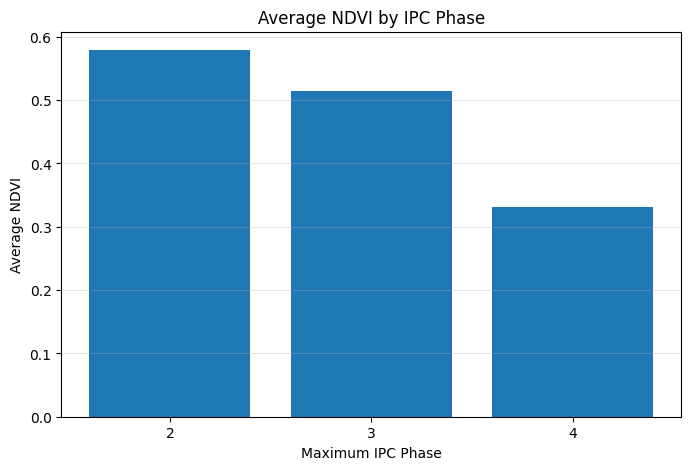

In [12]:
import matplotlib.pyplot as plt

# Create bar chart for average NDVI by IPC phase
plt.figure(figsize=(8, 5))

plt.bar(
    ndvi_by_ipc_phase.index.astype(str),
    ndvi_by_ipc_phase["mean_ndvi"]
)

plt.title("Average NDVI by IPC Phase")
plt.xlabel("Maximum IPC Phase")
plt.ylabel("Average NDVI")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

The bar chart shows a clear downward pattern in average NDVI as IPC severity increases.

IPC Phase 2 records have the highest average NDVI, IPC Phase 3 records have lower NDVI, and IPC Phase 4 records have the lowest NDVI.

This suggests that weaker vegetation health is associated with more severe food insecurity conditions. In practical terms, when vegetation becomes less green and less healthy, counties are more likely to experience higher IPC severity.

This supports the use of NDVI as an important environmental indicator in the drought and food security early-warning dataset.

## Visualize NDVI Anomaly by IPC Phase

In this step, I compare the average NDVI anomaly across IPC phases.

NDVI anomaly shows whether vegetation was better or worse than normal for that county and month.

A positive anomaly means vegetation was greener than normal.
A negative anomaly means vegetation was worse than normal.

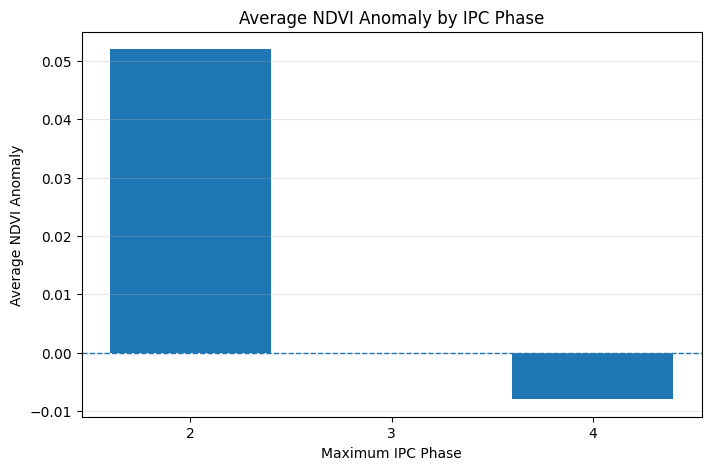

In [13]:
# Create bar chart for average NDVI anomaly by IPC phase
plt.figure(figsize=(8, 5))

plt.bar(
    ndvi_by_ipc_phase.index.astype(str),
    ndvi_by_ipc_phase["ndvi_anomaly"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average NDVI Anomaly by IPC Phase")
plt.xlabel("Maximum IPC Phase")
plt.ylabel("Average NDVI Anomaly")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

The NDVI anomaly chart compares vegetation conditions against what is normal for each county and month.

IPC Phase 2 has a positive NDVI anomaly, meaning vegetation was generally greener than normal during less severe food insecurity periods. IPC Phase 3 is close to normal, while IPC Phase 4 has a slightly negative anomaly, meaning vegetation was somewhat below normal during more severe food insecurity periods.

This suggests that worse food insecurity is associated with weaker vegetation conditions, although the anomaly signal is not very strong. This means NDVI anomaly is useful, but it should be combined with rainfall and other indicators for a stronger early-warning model.

## Compare Rainfall and NDVI by IPC Phase

In this step, I compare rainfall and NDVI indicators across IPC phases.

This helps check whether higher food insecurity severity is linked with both lower rainfall and weaker vegetation health.

In [14]:
# Compare rainfall and NDVI indicators by IPC phase
rainfall_ndvi_by_ipc = master.groupby("max_ipc_phase")[
    [
        "rainfall_3_month_avg",
        "rainfall_6_month_avg",
        "mean_ndvi",
        "ndvi_3_month_mean",
        "ndvi_6_month_mean",
        "ndvi_anomaly",
        "phase_3_plus_percentage"
    ]
].mean().round(3)

rainfall_ndvi_by_ipc

,rainfall_3_month_avg,rainfall_6_month_avg,mean_ndvi,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly,phase_3_plus_percentage
max_ipc_phase,,,,,,,
2,54.909,53.238,0.579,0.622,0.605,0.052,0.000
3,44.555,33.509,0.514,0.533,0.493,-0.000,0.098
4,26.046,19.304,0.331,0.354,0.317,-0.008,0.284


### Interpretation

The comparison shows that rainfall and NDVI both decrease as IPC severity increases.

IPC Phase 2 records have the highest rainfall averages and the highest NDVI values. IPC Phase 3 records show lower rainfall and lower NDVI. IPC Phase 4 records have the lowest rainfall and weakest vegetation health.

At the same time, the Phase 3+ population percentage increases from Phase 2 to Phase 4. This suggests that more severe food insecurity is associated with drier rainfall conditions, weaker vegetation health, and a larger share of the population facing crisis-level food insecurity.

This supports the use of rainfall and NDVI together as important environmental indicators for a drought and food security early-warning dataset.

## Save the Final Master Dataset

In this step, I save the merged dataset that combines IPC food insecurity outcomes, CHIRPS rainfall indicators, and MODIS NDVI vegetation indicators.

This final dataset will be used for deeper analysis and later for building a drought and food security early-warning model.

In [15]:
# Save the final merged master dataset
output_path = "../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv"

master.to_csv(output_path, index=False)

print("Final master dataset saved to:")
print(output_path)

print("Final dataset shape:", master.shape)

Final master dataset saved to:
../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv
Final dataset shape: (322, 19)


### Interpretation

The final master dataset has been saved successfully.

This dataset combines three major parts of the project:

- IPC food insecurity outcomes
- CHIRPS rainfall features
- MODIS NDVI vegetation features

This file is now the main analysis-ready dataset for the drought and food security early-warning system.

## Summary of This Notebook

In this notebook, I merged MODIS NDVI vegetation features with the existing IPC + rainfall modeling dataset.

The final dataset contains 322 rows and 19 columns. It combines IPC food insecurity outcomes, CHIRPS rainfall indicators, and MODIS NDVI vegetation indicators.

The initial analysis showed that higher IPC phases are associated with lower rainfall and lower NDVI values. This suggests that rainfall and vegetation health are useful environmental indicators for drought and food security early warning.

The final merged dataset was saved as:

`02_data/processed/ipc_rainfall_ndvi_master_dataset.csv`

This dataset is now ready for deeper exploratory analysis and future modeling.